# Collecting data from Reddit's API
Emilio Lehoucq - 11/27/23

## Installing libraries

In [1]:
pip install praw

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.0/191.0 kB 4.3 MB/s eta 0:00:00


## Importing libraries

In [132]:
import praw
from time import sleep
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
pd.set_option('display.max_rows', None)

## Collecting data

In [81]:
# Authenticating
reddit = praw.Reddit(
    # https://praw.readthedocs.io/en/stable/getting_started/authentication.html#
    # https://www.reddit.com/prefs/apps/
    client_id="XXXXXXXXXXXXXX",
    client_secret="XXXXXXXXXXXXXX",
    password="XXXXXXXXXXXXXX",
    user_agent="XXXXXXXXXXXXXX",
    username="XXXXXXXXXXXXXX",
    # https://www.reddit.com/r/redditdev/comments/levqr0/it_appears_that_you_are_using_praw_in_an/
    check_for_async=False
)

# Creating dictionary to store data
data = {
    # https://praw.readthedocs.io/en/stable/code_overview/models/submission.html
    'subreddit': [],
    'author': [],
    'comments': [],
    'created_utc': [],
    'is_self': [],
    'name': [],
    'num_comments': [],
    'permalink': [],
    'score': [],
    'selftext': [],
    'stickied': [],
    'title': [],
    'upvote_ratio': [],
    'url': []
}

# subreddits I want posts from
subreddits = ['Meditation', 'Mindfulness', 'Headspace', 'Buddhism']

# Number of posts per subreddit
NUM_POSTS = 795 # seems to be the limit

# Iterating over subreddits
counter = 0
for subreddit in subreddits:
  # Iterating over number of posts per subreddit
  for submission in reddit.subreddit(subreddit).hot(limit=NUM_POSTS):
    data['subreddit'].append(subreddit)
    data['author'].append(submission.author)
    data['comments'].append(submission.comments)
    data['created_utc'].append(submission.created_utc)
    data['is_self'].append(submission.is_self)
    data['name'].append(submission.name)
    data['num_comments'].append(submission.num_comments)
    data['permalink'].append(submission.permalink)
    data['score'].append(submission.score)
    data['selftext'].append(submission.selftext)
    data['stickied'].append(submission.stickied)
    data['title'].append(submission.title)
    data['upvote_ratio'].append(submission.upvote_ratio)
    data['url'].append(submission.url)
    # Run into TooManyRequests: received 429 HTTP response, so decided to add some sleep time
    # Not sure whether this is the right time to sleep. I thought praw handled rate limits
    sleep(1)
  # I don't want to wait 10 minutes after the last subreddit...
  if counter < len(subreddits)-1:
    sleep(600)
    counter += 1

## Checking data looks ok

In [116]:
# Converting to data frame
df = pd.DataFrame(data)

In [115]:
# Exploring what data looks like
df.head()

,subreddit,author,comments,created_utc,is_self,name,num_comments,permalink,score,selftext,stickied,title,upvote_ratio,url
0,Meditation,AutoModerator,"(k8ljs7i, k7bou3n, k7g0nhr, k7nncir, k8xojd5, ...",1.698797e+09,True,t3_17kz8ri,37,/r/Meditation/comments/17kz8ri/monthly_meditat...,9,"Hello friends,\n\nReady to make meditation a h...",True,Monthly Meditation Challenge - November 2023,0.91,https://www.reddit.com/r/Meditation/comments/1...
1,Meditation,afropunk95,"(kaylnm8, kaylzfe, kaz2339, kaysmeo, kayt524, ...",1.701082e+09,True,t3_18505xv,16,/r/Meditation/comments/18505xv/i_cant_stop_cry...,29,"So I discovered breath-work not that long ago,...",False,I can't stop crying,0.94,https://www.reddit.com/r/Meditation/comments/1...
2,Meditation,pasdutout07,"(kayur9c, kays8wu, kayxcij, kaywyeq, kaz0h0u, ...",1.701087e+09,True,t3_1851jgy,22,/r/Meditation/comments/1851jgy/can_one_reach_a...,19,They only thing you have beside food is medita...,False,Can one reach a point where they don't feel bo...,0.95,https://www.reddit.com/r/Meditation/comments/1...
3,Meditation,Sinker12344,"(kaym7vd, kaymwre, kaykxue, kaz67fy, kayllbo, ...",1.701082e+09,True,t3_1850aai,27,/r/Meditation/comments/1850aai/this_feels_so_p...,15,Hello\n\nI've started meditating and my mind i...,False,This feels so pointless,0.90,https://www.reddit.com/r/Meditation/comments/1...
4,Meditation,Kadju123,"(kaz30sw, kaz60cs, kaz4ohp, kaz47t8, kazdwb3, ...",1.701093e+09,True,t3_18538wj,15,/r/Meditation/comments/18538wj/there_something...,6,I don't know if this is the right place to put...,False,There' something I don't understand about emot...,0.88,https://www.reddit.com/r/Meditation/comments/1...


In [157]:
# Making sure I got posts for all subreddits
df['subreddit'].value_counts()
# Not sure why 794 for meditation, but no big deal

Mindfulness    795
Headspace      795
Buddhism       795
Meditation     794
Name: subreddit, dtype: int64

In [125]:
# Making sure data as expected
assert df.shape[1] == 14
assert df['subreddit'].isnull().sum() == 0
assert df['comments'].isnull().sum() == 0
assert df['created_utc'].isnull().sum() == 0
assert df['is_self'].isnull().sum() == 0
assert df['name'].isnull().sum() == 0
assert df['num_comments'].isnull().sum() == 0
assert df['permalink'].isnull().sum() == 0
assert df['score'].isnull().sum() == 0
assert df['selftext'].isnull().sum() == 0
assert df['stickied'].isnull().sum() == 0
assert df['title'].isnull().sum() == 0
assert df['upvote_ratio'].isnull().sum() == 0
assert df['url'].isnull().sum() == 0

In [126]:
df['author'].isna().value_counts()
# Not sure why some authors are none, but very few

False    3108
True       71
Name: author, dtype: int64

In [112]:
# Taking a look at what the data with None authors looks like
df[df['author'].isna()]

,subreddit,author,comments,created_utc,is_self,name,num_comments,permalink,score,selftext,stickied,title,upvote_ratio,url
622,Meditation,None,"(k7vzu9z, k7w753r, k7xnh9v)",1.699153e+09,True,t3_17o2re9,6,/r/Meditation/comments/17o2re9/stopped_meditat...,3,I used to meditate every other day and recentl...,False,Stopped meditation and going back in a rut again,0.81,https://www.reddit.com/r/Meditation/comments/1...
747,Meditation,None,"(k76nmmp, k75a834, k75ow35, k75x146, k772v7x, ...",1.698701e+09,True,t3_17k46qi,35,/r/Meditation/comments/17k46qi/starting_to_fee...,25,I have been an overthinker and a worrier all m...,False,"Starting to feel a change, are these feelings ...",1.00,https://www.reddit.com/r/Meditation/comments/1...
825,Mindfulness,None,(kafn1rj),1.700729e+09,True,t3_181wsdv,1,/r/Mindfulness/comments/181wsdv/thoughts_on_he...,3,So essentially I want to commit to the Vipassa...,False,Thoughts on headaches and derealization,1.00,https://www.reddit.com/r/Mindfulness/comments/...
972,Mindfulness,None,"(k72nz53, k7356dp, k73t10y, k7587i3, k736f0b, ...",1.698643e+09,True,t3_17jm195,9,/r/Mindfulness/comments/17jm195/having_these_t...,12,"\_ Trillions of dollars in the world, and I am...",False,Having these thoughts makes me regret not impr...,0.84,https://www.reddit.com/r/Mindfulness/comments/...
1030,Mindfulness,None,"(k5qk4k8, k5tcqaw, k5pu45u, k5q4ak7, k5qinld, ...",1.697822e+09,True,t3_17cgd0r,28,/r/Mindfulness/comments/17cgd0r/how_do_you_min...,33,"I am a very ""sweet looking"" individual. Part o...",False,How do you mindfully advocate for yourself in ...,0.93,https://www.reddit.com/r/Mindfulness/comments/...
1064,Mindfulness,None,"(k53stam, k53usp6, k54ilwo, k53rm89, k541zb4, ...",1.697443e+09,True,t3_1790r8e,27,/r/Mindfulness/comments/1790r8e/how_do_you_get...,20,"I'll do it. For few weeks, maybe a month - if ...",False,How do you get out of a vicious cycle? I don't...,0.83,https://www.reddit.com/r/Mindfulness/comments/...
1106,Mindfulness,None,"(k4af5cw, k4aovs5, k4bmrfg, k4eb2zv, k4be6uu, ...",1.696952e+09,True,t3_174o9py,22,/r/Mindfulness/comments/174o9py/how_do_you_app...,12,"I get lost or off track often, getting trapped...",False,How do you approach “negative/painful emotions?”,0.88,https://www.reddit.com/r/Mindfulness/comments/...
1119,Mindfulness,None,"(k407qf5, k40oydc, k404wn5, k427cx8, k429mwh, ...",1.696780e+09,True,t3_1732a9w,22,/r/Mindfulness/comments/1732a9w/do_you_think_m...,17,I’ve been trying to meditate for a while now. ...,False,Do you think mindfulness is being over complic...,0.95,https://www.reddit.com/r/Mindfulness/comments/...
1124,Mindfulness,None,"(k3x6qth, k3xdi56, k3x3jsm, k3zx8sf)",1.696721e+09,False,t3_172jz6n,12,/r/Mindfulness/comments/172jz6n/the_unalome_is...,98,,False,The unalome is comforting when I get discouraged,0.95,https://i.redd.it/f585q7ou5vsb1.jpg
1136,Mindfulness,None,"(k3te11j, k3tpgdv, k3t0w45, k3sutq4, k3u8ddq, ...",1.696635e+09,True,t3_171r9s2,28,/r/Mindfulness/comments/171r9s2/what_advice_or...,24,\n\nI’m posting this because I am at loss at w...,False,"What advice, or book would you give to a depre...",0.92,https://www.reddit.com/r/Mindfulness/comments/...


In [185]:
# Number of posts with text (rather than image, video)
print(df[df['selftext'] != ''].shape)

# Proportion of posts with text
df[df['selftext'] != ''].shape[0] / df.shape[0]

(2860, 14)


0.8996539792387543

Quantiles: [  240.75   442.5    862.5  33164.  ] 

Number of posts 1500 characters or more: 293



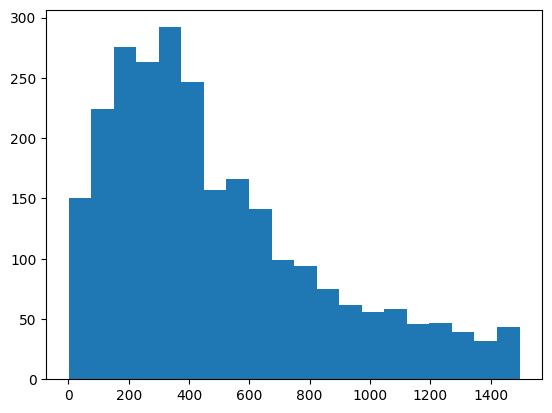

In [183]:
# Exploring how long the text is (if there is text in the first place)
characters = [len(text) for text in df['selftext'] if text != '']

# Quantiles of distribution of number of characters in posts
print("Quantiles:", np.quantile(characters, [0.25, 0.5, 0.75, 1]), '\n')

# Number of posts equal to or above threshold
THRESHOLD = 1500
print(f'Number of posts {THRESHOLD} characters or more: {len([char for char in characters if char >= THRESHOLD])}\n')

# Plotting distribution below threshold
plt.hist([char for char in characters if char < THRESHOLD], bins = 20)
plt.show()

## Exporting data to CSV

In [113]:
df.to_csv('reddit_mindfulness.csv')